In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

True

In [2]:

llm = ChatGroq(
    model="llama-3.1-8b-instant"
)

In [3]:
# define the state type

class BlogsState(TypedDict):
    title: str
    outline: str
    content: str
    evaluation: str

In [4]:
# graph define 

graph = StateGraph(BlogsState)

In [5]:
def create_outline(state: BlogsState) -> BlogsState:
    messages = [
        ("system", "You are a helpful assistant that creates outlines for blog posts."),
        ("human", f"Create an outline for a blog post titled '{state['title']}'"),
    ]

    ai_msg = llm.invoke(messages)

    state['outline'] = ai_msg.content
    
    return state

In [6]:
def write_content(state: BlogsState) -> BlogsState:
    messages = [
        ("system", "You are a helpful assistant that writes blog content based on an outline."),
        ("human", f"Write a blog post based on the following outline: {state['outline']}"),
    ]

    ai_msg = llm.invoke(messages)

    state['content'] = ai_msg.content
    
    return state

In [7]:
def evaluate_content(state: BlogsState) -> BlogsState:
    messages = [
        ("system", "You are a helpful assistant that evaluates blog content."),
        ("human", f"Evaluate the following blog content: {state['content']}"),
    ]

    ai_msg = llm.invoke(messages)

    state['evaluation'] = ai_msg.content
    
    return state

In [8]:
# define nodes 

graph.add_node("create_outline",create_outline)
graph.add_node("write_content",write_content)
graph.add_node("evaluate_content", evaluate_content)


# define edges
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","write_content")
graph.add_edge("write_content","evaluate_content")
graph.add_edge("evaluate_content",END)

# create the workflow

workflow = graph.compile()

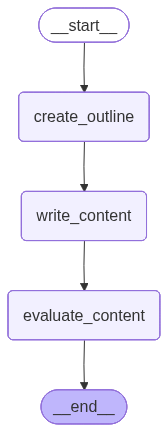

In [9]:
graph.compile()

In [10]:
# execute the graph

initial_state = {'title': 'Is men is safe in India?'}
final_state = workflow.invoke(initial_state)

print(final_state)


{'title': 'Is men is safe in India?', 'outline': "**Title:** Is India Safe for Men?\n\n**Introduction:**\n- Brief overview of India's reputation for safety\n- Importance of understanding the current situation for men traveling or living in India\n- Thesis statement: While safety concerns exist, India can be a safe destination for men with proper precautions and knowledge\n\n**Section 1: Safety Concerns in India**\n- Overview of common safety concerns for men in India (e.g., scams, harassment, crime)\n- Statistics on crime rates and safety incidents affecting men in India\n- Discussion of the impact of these concerns on male travelers and residents\n\n**Section 2: Types of Crimes Affecting Men in India**\n- Breakdown of specific crimes affecting men in India (e.g., theft, assault, scams)\n- Discussion of the areas and situations most prone to these crimes\n- Examples of how to avoid or minimize the risk of falling victim to these crimes\n\n**Section 3: Areas in India Considered Safe for

In [11]:
print(final_state['outline'])

**Title:** Is India Safe for Men?

**Introduction:**
- Brief overview of India's reputation for safety
- Importance of understanding the current situation for men traveling or living in India
- Thesis statement: While safety concerns exist, India can be a safe destination for men with proper precautions and knowledge

**Section 1: Safety Concerns in India**
- Overview of common safety concerns for men in India (e.g., scams, harassment, crime)
- Statistics on crime rates and safety incidents affecting men in India
- Discussion of the impact of these concerns on male travelers and residents

**Section 2: Types of Crimes Affecting Men in India**
- Breakdown of specific crimes affecting men in India (e.g., theft, assault, scams)
- Discussion of the areas and situations most prone to these crimes
- Examples of how to avoid or minimize the risk of falling victim to these crimes

**Section 3: Areas in India Considered Safe for Men**
- Overview of popular destinations considered safe for men (

In [12]:
print(final_state['evaluation'])

**Overall Evaluation:**

The blog content is informative, well-researched, and provides valuable insights into the safety concerns for men traveling or living in India. The author has structured the content in a logical and easy-to-follow manner, making it accessible to readers. The inclusion of statistics, examples, and tips provides a comprehensive understanding of the safety concerns and how to mitigate them.

**Strengths:**

1. **Comprehensive approach:** The blog covers various aspects of safety concerns in India, including scams, harassment, and crime.
2. **Practical tips:** The author provides actionable advice on how to stay safe while traveling or living in India, such as being aware of surroundings, using reputable transportation services, and staying connected.
3. **Use of statistics:** The inclusion of statistics from the National Crime Records Bureau (NCRB) adds credibility to the content and highlights the severity of the safety concerns.
4. **Regional focus:** The blog h